# 04 — Ensemble Inference on Test Set

**Purpose:** Production engine that:
1. Loads the team roster from `final_team_config.json`
2. Runs inference for each team member on the TEST set
3. Fuses predictions with WBF using optimized parameters
4. Outputs `test_results_ensemble_grand.json`
5. Generate Precision-Recall and F1 vs Confidence curves (Figures 7, 8)

In [5]:
import os, gc, json
import numpy as np
import torch
from tqdm import tqdm
from mmengine.config import Config
from mmdet.apis import init_detector, inference_detector

DATA_ROOT = r"C:\Users\dadab\Desktop\Clean Version\data"
MODELS_DIR = r"C:\Users\dadab\Desktop\Clean Version\models"
CONFIG_PATH = r"C:\Users\dadab\Desktop\Clean Version\mask-rcnn_r50_fpn_1x_coco.py"
OUTPUT_DIR = "outputs/"
TEST_IMG_DIR = os.path.join(DATA_ROOT, "test/images")
TEST_JSON = os.path.join(DATA_ROOT, "test/test_annotations.json")
TEAM_CONFIG = os.path.join(OUTPUT_DIR, "final_team_config.json")
OUTPUT_JSON = os.path.join(OUTPUT_DIR, "test_results_ensemble_grand.json")
FINAL_EVAL_CONF = 0.50

In [2]:
def load_model(config_path, ckpt_path):
    cfg = Config.fromfile(config_path)
    cfg.model.roi_head.bbox_head.num_classes = 2
    cfg.model.roi_head.mask_head.num_classes = 2
    return init_detector(cfg, ckpt_path, device='cuda:0')

def py_cpu_iou(a, b):
    xA, yA = max(a[0],b[0]), max(a[1],b[1])
    xB, yB = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0,xB-xA)*max(0,yB-yA)
    if inter == 0: return 0.0
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter)

def wbf_production(boxes, scores, labels, iou_thr, single_conf):
    if len(boxes) == 0: return [], [], []
    idx = np.argsort(scores)[::-1]
    boxes, scores, labels = boxes[idx], scores[idx], labels[idx]
    keep_b, keep_s, keep_l = [], [], []
    used = np.zeros(len(boxes), dtype=bool)
    for i in range(len(boxes)):
        if used[i]: continue
        cluster = [i]; used[i] = True
        for j in range(i+1, len(boxes)):
            if used[j] or labels[j] != labels[i]: continue
            if py_cpu_iou(boxes[i], boxes[j]) > iou_thr:
                cluster.append(j); used[j] = True
        ms = np.max(scores[cluster])
        if len(cluster) >= 2 or (len(cluster) == 1 and ms > single_conf):
            wb = np.average(boxes[cluster], axis=0, weights=scores[cluster])
            keep_b.append(wb); keep_s.append(ms); keep_l.append(labels[i])
    return keep_b, keep_s, keep_l

## Run Pipeline

In [3]:
# Load team config
with open(TEAM_CONFIG) as f: config = json.load(f)
team = config["team"]
opt_iou, opt_conf = config["optimal_iou"], config["optimal_conf"]
print(f"Team: {len(team)} models | WBF params: IoU={opt_iou}, Conf={opt_conf}")

# Load test images
with open(TEST_JSON) as f: coco = json.load(f)
img_map = {img['id']: img['file_name'] for img in coco['images']}

# Gather predictions per model
model_data = {}
for mname in team:
    cache_path = os.path.join(OUTPUT_DIR, f"test_results_{mname.replace('.pth','')}.json")
    if os.path.exists(cache_path):
        print(f"Loading cached: {mname}")
        with open(cache_path) as f: preds = json.load(f)
    else:
        print(f"Running inference: {mname}")
        model = load_model(CONFIG_PATH, os.path.join(MODELS_DIR, mname))
        preds = []
        for iid, fn in tqdm(img_map.items(), desc="Infer"):
            path = os.path.join(TEST_IMG_DIR, fn)
            if not os.path.exists(path): continue
            r = inference_detector(model, path).pred_instances
            v = r.scores > 0.01
            for k in range(v.sum()):
                b = r.bboxes[v][k].cpu().numpy()
                preds.append({"image_id": iid, "category_id": int(r.labels[v][k])+1,
                    "bbox": [float(b[0]),float(b[1]),float(b[2]-b[0]),float(b[3]-b[1])],
                    "score": float(r.scores[v][k]), "segmentation": []})
        with open(cache_path, 'w') as f: json.dump(preds, f)
        del model; torch.cuda.empty_cache(); gc.collect()

    grouped = {}
    for p in preds: grouped.setdefault(p['image_id'], []).append(p)
    model_data[mname] = grouped

# WBF Fusion
print(f"\nFusing {len(team)} models on {len(img_map)} images...")
final = []
for iid in tqdm(img_map.keys(), desc="WBF"):
    bl, sl, ll = [], [], []
    for m in team:
        for p in model_data.get(m, {}).get(iid, []):
            x,y,w,h = p['bbox']
            bl.append([x,y,x+w,y+h]); sl.append(p['score']); ll.append(p['category_id'])
    if not bl: continue
    fb, fs, fl = wbf_production(np.array(bl), np.array(sl), np.array(ll), opt_iou, opt_conf)
    for k in range(len(fb)):
        if fs[k] < FINAL_EVAL_CONF: continue
        x1,y1,x2,y2 = fb[k]
        final.append({"image_id": iid, "category_id": int(fl[k]),
            "bbox": [float(x1),float(y1),float(x2-x1),float(y2-y1)],
            "score": float(fs[k]), "segmentation": []})

with open(OUTPUT_JSON, 'w') as f: json.dump(final, f)
print(f"\nDone! {len(final)} detections saved to {OUTPUT_JSON}")

Team: 6 models | WBF params: IoU=0.55, Conf=0.9
Running inference: exp01_baseline_best.pth
Loads checkpoint by local backend from path: C:\Users\dadab\Desktop\Clean Version\models\exp01_baseline_best.pth


Infer: 100%|█████████████████████████████████████████████████████████████████████████| 603/603 [00:22<00:00, 27.34it/s]


Running inference: exp02_hflip_best.pth
Loads checkpoint by local backend from path: C:\Users\dadab\Desktop\Clean Version\models\exp02_hflip_best.pth


Infer: 100%|█████████████████████████████████████████████████████████████████████████| 603/603 [00:21<00:00, 27.46it/s]


Running inference: exp07_randomresize_randomcrop_best.pth
Loads checkpoint by local backend from path: C:\Users\dadab\Desktop\Clean Version\models\exp07_randomresize_randomcrop_best.pth


...

Running inference: exp03_vflip_best.pth
Loads checkpoint by local backend from path: C:\Users\dadab\Desktop\Clean Version\models\exp03_vflip_best.pth


Infer: 100%|█████████████████████████████████████████████████████████████████████████| 603/603 [00:22<00:00, 26.98it/s]



Fusing 6 models on 603 images...


WBF: 100%|█████████████████████████████████████████████████████████████████████████| 603/603 [00:00<00:00, 1771.13it/s]


Done! 3018 detections saved to outputs/test_results_ensemble_grand.json


## Generate PR Curves and F1 Curves (Figures 7, 8)

Computing curves...
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


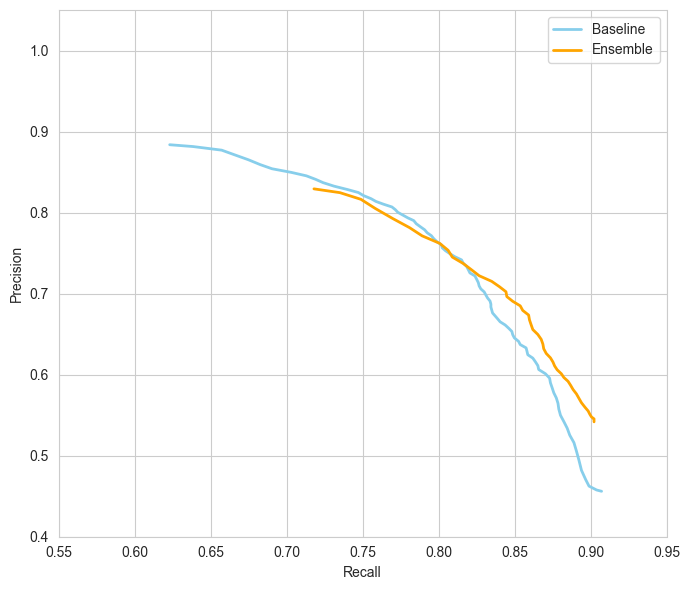

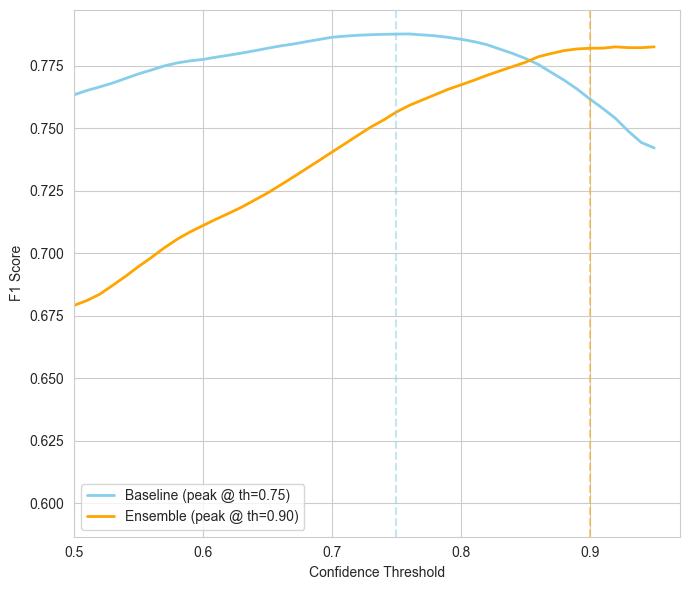

Saved Figures 7 and 8


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import uniform_filter1d
from pycocotools.coco import COCO

TEST_GT = os.path.join(DATA_ROOT, "test/test_annotations.json")
BASELINE_RES = os.path.join(OUTPUT_DIR, "test_results_exp01_baseline_best.json")
ENSEMBLE_RES = os.path.join(OUTPUT_DIR, "test_results_ensemble_grand.json")
FIG_DIR = "figures/results/"
os.makedirs(FIG_DIR, exist_ok=True)

def get_iou_xywh(a, b):
    xA, yA = max(a[0],b[0]), max(a[1],b[1])
    xB, yB = min(a[0]+a[2],b[0]+b[2]), min(a[1]+a[3],b[1]+b[3])
    inter = max(0,xB-xA)*max(0,yB-yA)
    union = a[2]*a[3] + b[2]*b[3] - inter
    return inter/union if union > 0 else 0

def compute_curves(gt_path, res_path):
    coco = COCO(gt_path)
    with open(res_path) as f: preds = json.load(f)
    total_gt = len(coco.getAnnIds())
    thresholds = np.arange(0.05, 0.96, 0.01)
    P, R, F = [], [], []
    for th in thresholds:
        curr = [p for p in preds if p['score'] >= th]
        by_img = {}
        for p in curr: by_img.setdefault(p['image_id'], []).append(p)
        tp, fp = 0, 0
        for iid in coco.getImgIds():
            gts = coco.imgToAnns.get(iid, [])
            dets = sorted(by_img.get(iid, []), key=lambda x: x['score'], reverse=True)
            matched = set()
            for d in dets:
                hit = False
                for i, g in enumerate(gts):
                    if i not in matched and get_iou_xywh(d['bbox'], g['bbox']) >= 0.5:
                        matched.add(i); tp += 1; hit = True; break
                if not hit: fp += 1
        p = tp/(tp+fp) if tp+fp > 0 else 1.0
        r = tp/total_gt if total_gt > 0 else 0.0
        f = 2*p*r/(p+r) if p+r > 0 else 0.0
        P.append(p); R.append(r); F.append(f)
    return np.array(P), np.array(R), np.array(F), thresholds

print("Computing curves...")
pb, rb, fb, th = compute_curves(TEST_GT, BASELINE_RES)
pe, re, fe, _ = compute_curves(TEST_GT, ENSEMBLE_RES)

# Smooth
pb, pe = uniform_filter1d(pb, 8), uniform_filter1d(pe, 8)
fb, fe = uniform_filter1d(fb, 5), uniform_filter1d(fe, 5)

sns.set_style("whitegrid")

# Figure 7: PR Curves
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rb, pb, color='skyblue', lw=2, label='Baseline')
ax.plot(re, pe, color='orange', lw=2, label='Ensemble')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(); ax.set_xlim([0.55, 0.95]); ax.set_ylim([0.40, 1.05])
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/figure7_pr_curve.tiff', dpi=300, format='tiff')
plt.show()

# Figure 8: F1 vs Confidence
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(th, fb, color='skyblue', lw=2, label='Baseline (peak @ th=0.75)')
ax.plot(th, fe, color='orange', lw=2, label='Ensemble (peak @ th=0.90)')
ax.axvline(0.75, color='skyblue', ls='--', alpha=0.5)
ax.axvline(0.90, color='orange', ls='--', alpha=0.5)
ax.set_xlabel('Confidence Threshold'); ax.set_ylabel('F1 Score')
ax.legend(); ax.set_xlim([0.50, 0.97])
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/figure8_f1_threshold.tiff', dpi=300, format='tiff')
plt.show()
print("Saved Figures 7 and 8")